# 3-coupled SIR model

This notebook will serve as a test environment for the coupled SIR model.

Recall that this first iteration of the coupled model is given by
\begin{align*}
\dot{S}_1 &= -\left(\beta_1 I_1 + \beta_2 I_2 + \beta_3 I_3\right)S_1\\
\dot{I}_1 &= \left(S_1+S_2+S_3\right)\beta_1 I_1 - \gamma_1 I_1\\
\dot{R}_1 &= \gamma_1 I_1\\[2ex]
\dot{S}_2 &= -\left(\beta_1 I_1 + \beta_2 I_2 + \beta_3 I_3\right)S_2\\
\dot{I}_2 &= \left(S_1+S_2+S_3\right)\beta_2 I_2 - \gamma_2 I_2\\
\dot{R}_2 &= \gamma_2 I_2\\[2ex]
\dot{S}_3 &= -\left(\beta_1 I_1 + \beta_2 I_2 + \beta_3 I_3\right)S_3\\
\dot{I}_3 &= \left(S_1+S_2+S_3\right)\beta_3 I_3 - \gamma_3 I_3\\
\dot{R}_3 &= \gamma_3 I_3\\[2ex]
\end{align*}


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# RHS of system
def SIR_3(t, S, p):
    
    
    s1, i1, r1, s2, i2, r2, s3, i3, r3 = S
    
    return np.array([-(p[0]*i1 + p[1]*i2 + p[2]*i3)*(s1),
                     (s1 + s2 + s3)*p[0]*i1 - p[3]*i1,
                     p[3]*i1,
            
                     -(p[0]*i1 + p[1]*i2 + p[2]*i3)*s2,
                     (s1 + s2 + s3)*p[1]*i2 - p[4]*i2,
                     p[4]*i2,
                     
                     -(p[0]*i1 + p[1]*i2 + p[2]*i3)*s3,
                     (s1 + s2 + s3)*p[2]*i3 - p[5]*i3,
                     p[5]*i3
                     ])



# ODE integration
def RK4_sys(t0,tn,n,y0,diff, args):
    h = abs((tn-t0)/n)
    rows = len(y0)
    
    t = np.linspace(t0,tn,n+1)
    y = np.zeros((rows, n+1))
    
    y[:,0] = y0[:]
    
    for k in range(n):
        
        A = diff(t[k],y[:,k], args)
        B = diff( t[k] + (h/2), y[:,k] + (A*h)/2, args)
        C = diff( t[k]+ (h/2), y[:,k] + (B*h)/2, args)
        D = diff( t[k] + h, y[:,k] + C*h, args)
        y[:,k+1] = y[:,k] + (h/6)*(A + 2*B + 2*C + D)
    return t,y




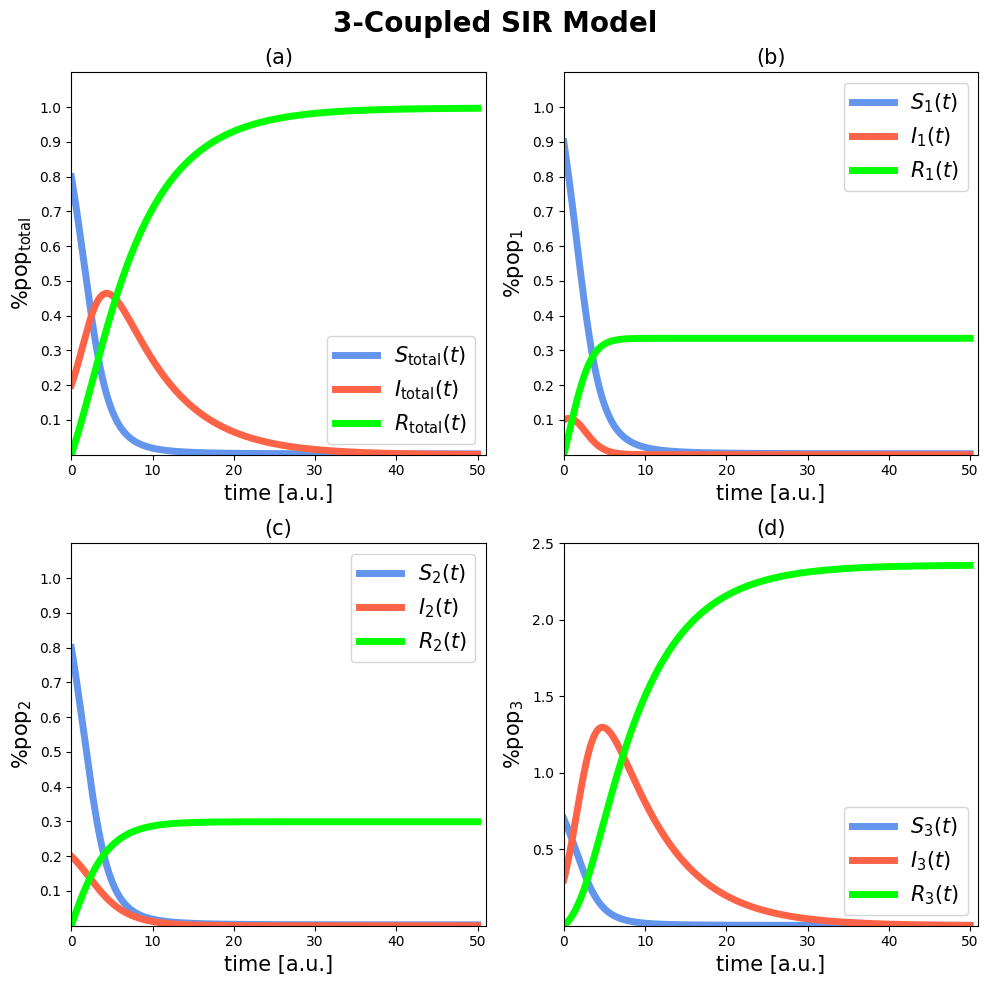

In [6]:
# setting initial parameters
s10 = 0.9
s20 = 0.8
s30 = 0.7

i10 = 1 - s10
i20 = 1 - s20
i30 = 1 - s30

r10 = 0.
r20 = 0.
r30 = 0.

S0 = np.array([s10, i10, r10, 
               s20, i20, r20,
               s30, i30, r30])

t0 = 0
tf = 50
n = 5000

# infectivity and recovery rates, respectively
beta1 = 0.45
beta2 = 0.10
beta3 = 0.35

gamma1 = 0.95
gamma2 = 0.35
gamma3 = 0.15

p = np.array([beta1, beta2, beta3,
              gamma1, gamma2, gamma3])


t, S = RK4_sys(t0, tf, n, S0, SIR_3, p)

S_total = np.sum(S[0:-1:3, :], axis = 0)/3
I_total = np.sum(S[1:-1:3, :], axis = 0)/3
R_total = np.sum(S[2:9:3, :], axis = 0)/3


S1 = S[0, :]
I1 = S[1, :]
R1 = S[2, :]

S2 = S[3, :]
I2 = S[4, :]
R2 = S[5, :]

S3 = S[6, :]
I3 = S[7, :]
R3 = S[8, :] 


fig1, ax1 = plt.subplots(2,2, figsize = (10,10))
ax1[0,0].plot(t, S_total, color = 'cornflowerblue', label = r'$S_{\text{total}}(t)$', linewidth = 5)
ax1[0,0].plot(t,I_total, color = 'tomato', label = r'$I_{\text{total}}(t)$', linewidth = 5)
ax1[0,0].plot(t,R_total, color = 'lime', label = r'$R_{\text{total}}(t)$', linewidth = 5)
ax1[0,0].legend(fontsize = 15)
ax1[0,0].set_xlabel("time [a.u.]", fontsize = 15)
ax1[0,0].set_ylabel(r"%$\text{pop}_{\text{total}}$", fontsize = 15)
ax1[0,0].set_ylim(0, 1.1)
ax1[0,0].set_xlim(t0, tf+1)
ax1[0,0].set_xticks(np.arange(t0, tf+1, 10))
ax1[0,0].set_yticks(np.arange(0.1, 1.1, 0.1))
ax1[0,0].set_title("(a)", fontsize = 15)

ax1[0,1].plot(t, S1, color = 'cornflowerblue', label = r'$S_{1}(t)$', linewidth = 5)
ax1[0,1].plot(t,I1, color = 'tomato', label = r'$I_{1}(t)$', linewidth = 5)
ax1[0,1].plot(t,R1, color = 'lime', label = r'$R_{1}(t)$', linewidth = 5)
ax1[0,1].legend(fontsize = 15)
ax1[0,1].set_xlabel("time [a.u.]", fontsize = 15)
ax1[0,1].set_ylabel(r"%$\text{pop}_{1}$", fontsize = 15)
ax1[0,1].set_ylim(0, 1.1)
ax1[0,1].set_xlim(t0, tf+1)
ax1[0,1].set_xticks(np.arange(t0, tf+1, 10))
ax1[0,1].set_yticks(np.arange(0.1, 1.1, 0.1))
ax1[0,1].set_title("(b)", fontsize = 15)

ax1[1,0].plot(t, S2, color = 'cornflowerblue', label = r'$S_{2}(t)$', linewidth = 5)
ax1[1,0].plot(t,I2, color = 'tomato', label = r'$I_{2}(t)$', linewidth = 5)
ax1[1,0].plot(t,R2, color = 'lime', label = r'$R_{2}(t)$', linewidth = 5)
ax1[1,0].legend(fontsize = 15)
ax1[1,0].set_xlabel("time [a.u.]", fontsize = 15)
ax1[1,0].set_ylabel(r"%$\text{pop}_{2}$", fontsize = 15)
ax1[1,0].set_ylim(0, 1.1)
ax1[1,0].set_xlim(t0, tf+1)
ax1[1,0].set_xticks(np.arange(t0, tf+1, 10))
ax1[1,0].set_yticks(np.arange(0.1, 1.1, 0.1))
ax1[1,0].set_title("(c)", fontsize = 15)

ax1[1,1].plot(t, S3, color = 'cornflowerblue', label = r'$S_{3}(t)$', linewidth = 5)
ax1[1,1].plot(t, I3, color = 'tomato', label = r'$I_{3}(t)$', linewidth = 5)
ax1[1,1].plot(t, R3, color = 'lime', label = r'$R_{3}(t)$', linewidth = 5)
ax1[1,1].legend(fontsize = 15)
ax1[1,1].set_xlabel("time [a.u.]", fontsize = 15)
ax1[1,1].set_ylabel(r"%$\text{pop}_{3}$", fontsize = 15)
ax1[1,1].set_ylim(0, 2.1)
ax1[1,1].set_xlim(t0, tf+1)
ax1[1,1].set_xticks(np.arange(t0, tf+1, 10))
ax1[1,1].set_yticks(np.arange(0.5, 3, 0.5))
ax1[1,1].set_title("(d)", fontsize = 15)
fig1.suptitle("3-Coupled SIR Model", fontweight = 'semibold', fontsize = 20)
fig1.tight_layout()

